# ❤️ Heart Disease Prediction System

##  Objective

The objective of this project is to build a machine learning model that can predict whether a person is at risk of heart disease based on their medical attributes. The model analyzes patient health data and learns patterns that indicate the likelihood of heart disease, helping in early detection and preventive healthcare.

---

## Dataset

The dataset used in this project is the **Heart Disease UCI Dataset**. It includes various medical attributes of patients such as:

* Age
* Sex
* Chest Pain Type
* Resting Blood Pressure
* Serum Cholesterol
* Fasting Blood Sugar
* Resting ECG Results
* Maximum Heart Rate Achieved
* Exercise Induced Angina
* Oldpeak (ST depression)
* Target (0 = No disease, 1 = Disease present)

This dataset is commonly used for binary classification problems in healthcare.

---

## Libraries Used

The following Python libraries are used in this project:

* pandas → Data loading and manipulation
* numpy → Numerical operations
* matplotlib → Data visualization
* seaborn → Statistical visualization
* scikit-learn → Machine learning model building and evaluation

---

## Workflow

The project follows these steps:

1. Import required libraries
2. Load the dataset
3. Perform data inspection (head, shape, columns)
4. Handle missing values (if any)
5. Perform Exploratory Data Analysis (EDA)

   * Target distribution
   * Age vs disease analysis
   * Correlation heatmap
6. Split dataset into features (X) and target (y)
7. Train-test split
8. Train Logistic Regression model
9. Make predictions on test data
10. Evaluate model performance

* Accuracy Score
* Confusion Matrix
* ROC Curve & AUC Score

11. Analyze feature importance
12. Draw conclusions and insights

---

## Final Goal

To develop a simple but effective classification model that can assist in predicting heart disease risk and support early medical decision-making.


# Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

# Load Dataset

In [ ]:
df = pd.read_csv("heart.csv")

# Basic Inspection

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (1025, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


# Data Cleaning


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


# EDA (Exploratory Data Analysis)

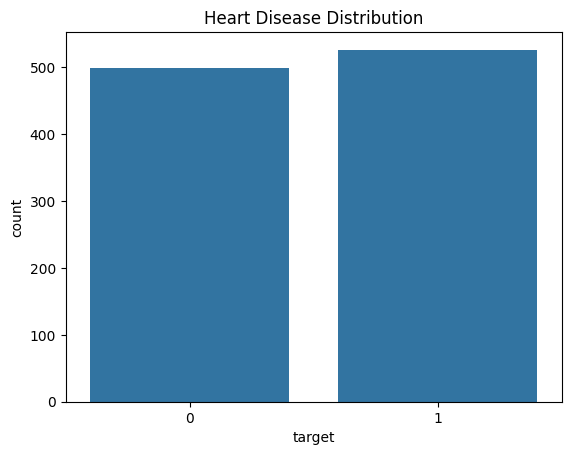

In [ ]:
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution")
plt.show()

# Age vs Disease

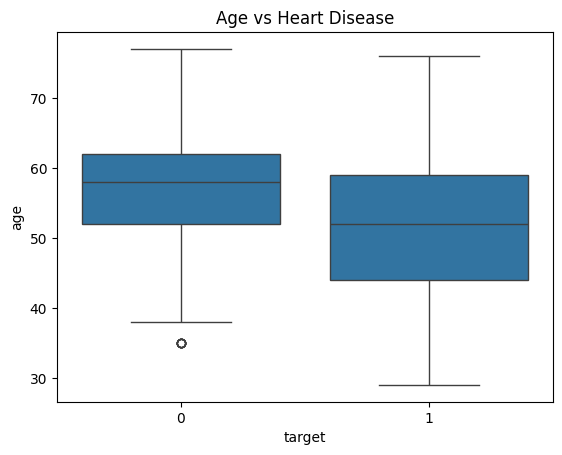

In [ ]:
sns.boxplot(x="target", y="age", data=df)
plt.title("Age vs Heart Disease")
plt.show()

# Correlation Heatmap

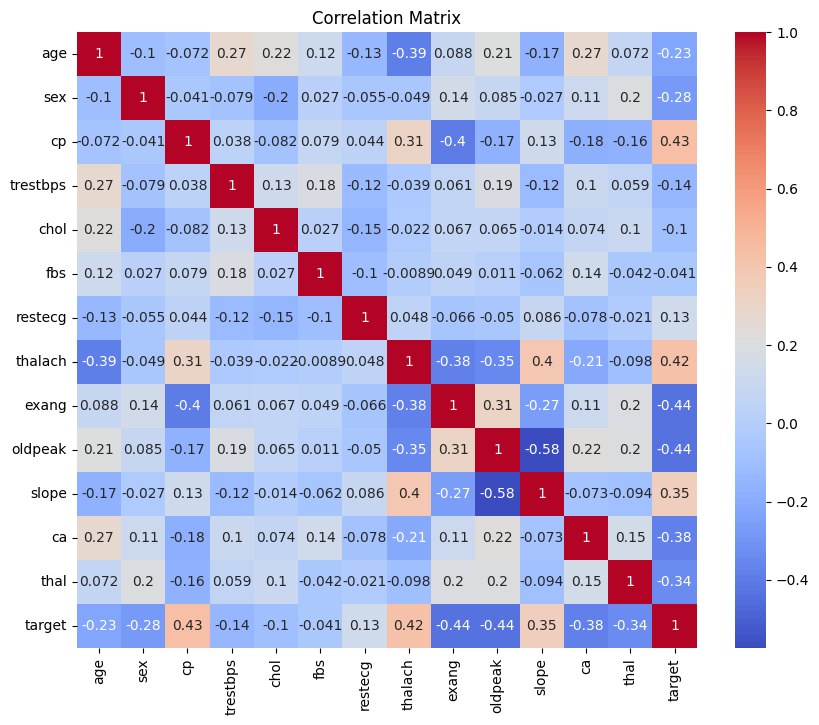

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Prepare Features & Target

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

# Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model via LogisticRegression.

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Predictions

In [ ]:
y_pred = model.predict(X_test)

# Accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.7951219512195122


# Confusion Matrix

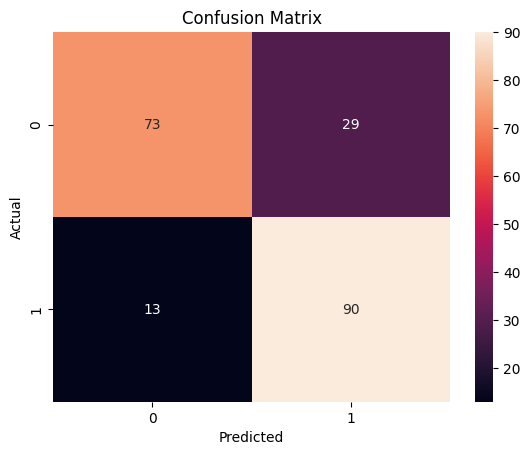

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve

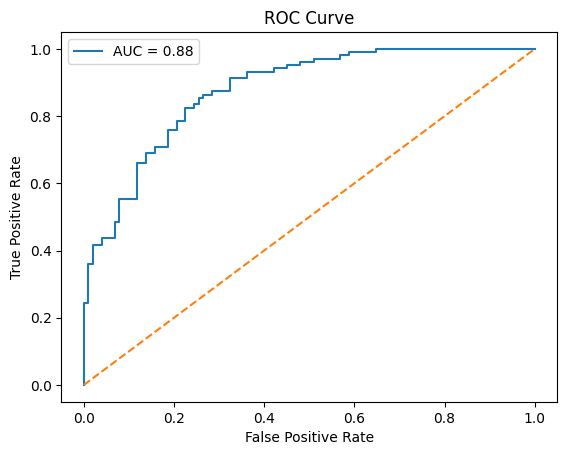

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Train Model via DecisionTree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9853658536585366


# Confusion Matrix

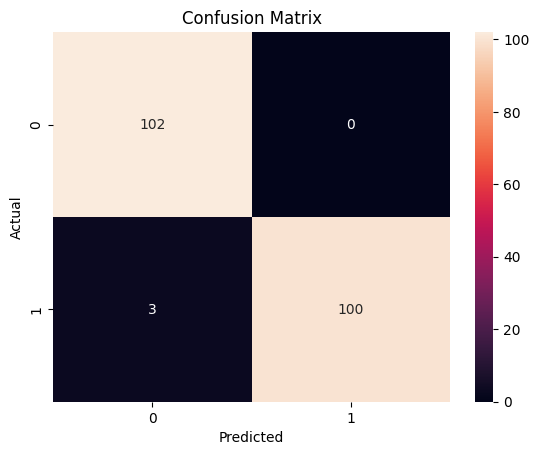

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve

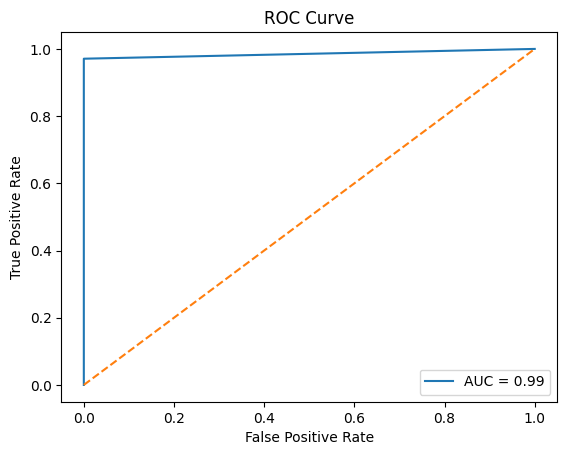

In [ ]:
y_prob = model_dt.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,2)))
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

##  Model Comparison: Logistic Regression vs Decision Tree

Two classification models were trained and evaluated on the dataset: Logistic Regression and Decision Tree.

- Logistic Regression achieved an accuracy of **79.5%**, demonstrating stable and reliable performance.
- Decision Tree achieved an accuracy of **98.5%**.

Logistic Regression provides a simpler and more generalized model, making it less prone to overfitting. On the other hand, Decision Tree can capture complex patterns in the data but may overfit if not properly controlled.

Based on the results, Logistic Regression shows consistent performance, while Decision Tree performance depends on model tuning.

Overall, Logistic Regression is preferred for its stability, while Decision Tree can be useful for capturing non-linear relationships.





#Feature Importance

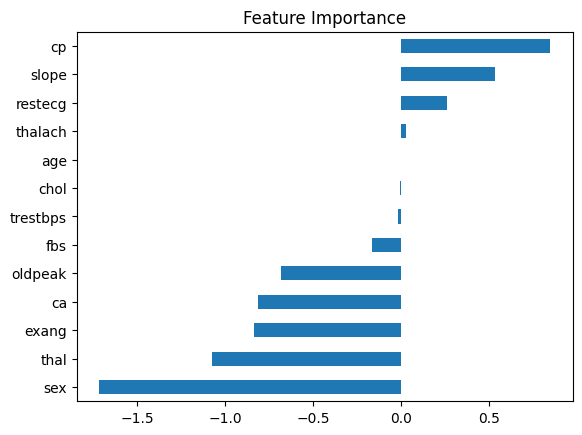

In [ ]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

## ✅ Conclusion

A machine learning model was developed to predict heart disease using patient data.

Two classification models were applied: Logistic Regression and Decision Tree.

The Logistic Regression model achieved an accuracy of approximately 79.5%, demonstrating stable and reliable performance. The Decision Tree model was also evaluated and achieved an accuracy of 98.5%, showing strong performance, showing its ability to capture more complex patterns in the data.

Evaluation metrics such as confusion matrix and ROC curve confirm the effectiveness of both models. Logistic Regression offers better generalization, while Decision Tree provides flexibility in handling non-linear relationships.

This project highlights the importance of machine learning in healthcare for early disease detection and decision support.